# SINDy on Vasicek / OU Short-Rate Dynamics

This notebook applies a from-scratch SINDy implementation to simulated Vasicek short-rate dynamics.

The goal is to check whether SINDy can recover the interpretable mean-reverting structure of the model.


In [11]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.simulation import simulate_vasicek
from src.discrete_sindy import fit_discrete_sindy, predict_discrete_sindy
from src.continous_sindy import fit_continuous_sindy, predict_derivative_continuous_sindy


## Helper function

This helper formats the learned coefficient vector as a readable equation.


In [12]:
def format_equation(feature_names, Xi, target_name="y", tolerance=1e-10):
    terms = []

    for name, coefficient in zip(feature_names, Xi[:, 0]):
        if abs(coefficient) <= tolerance:
            continue

        if name == "1":
            terms.append(f"{coefficient:.6f}")
        else:
            terms.append(f"{coefficient:.6f}*{name}")

    if not terms:
        return f"{target_name} = 0"

    return f"{target_name} = " + " + ".join(terms)


## Simulate Vasicek dynamics

The Vasicek short-rate model is:

`dr_t = kappa * (theta - r_t) dt + sigma dW_t`

It is the finance version of an Ornstein--Uhlenbeck mean-reverting process.


In [13]:
n_steps = 2000
dt = 0.01
kappa = 1.5
theta = 0.03
sigma = 0.02
r0 = 0.01

r = simulate_vasicek(
    n_steps=n_steps,
    dt=dt,
    kappa=kappa,
    theta=theta,
    sigma=sigma,
    r0=r0,
    seed=42,
)

R_full = r.reshape(-1, 1)
time = np.arange(n_steps) * dt


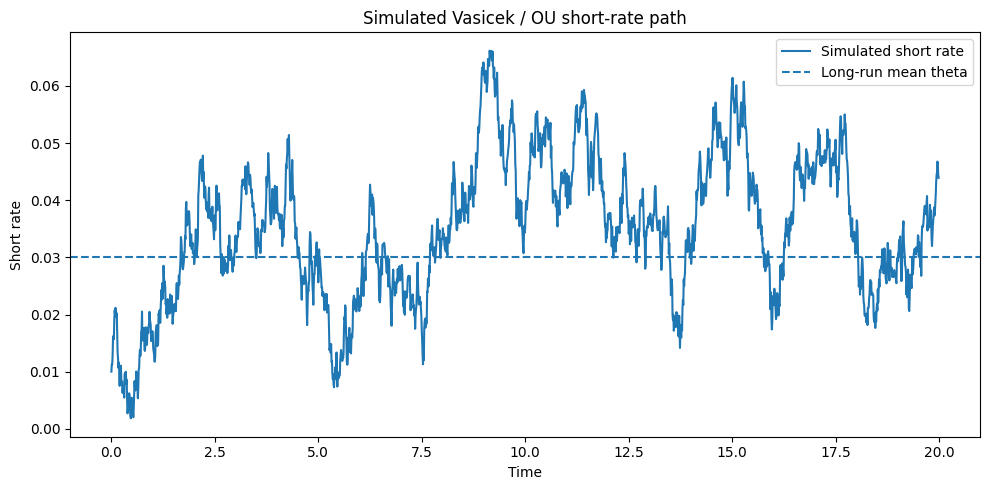

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(time, r, label="Simulated short rate")
plt.axhline(theta, linestyle="--", label="Long-run mean theta")
plt.xlabel("Time")
plt.ylabel("Short rate")
plt.title("Simulated Vasicek / OU short-rate path")
plt.legend()
plt.tight_layout()
plt.show()


## Discrete-time SINDy

We fit the one-step map:

`r_next ≈ F(r)`

For the Vasicek process, the Euler discretization implies:

`r_next ≈ kappa * theta * dt + (1 - kappa * dt) * r`


In [15]:
X_discrete = r[:-1].reshape(-1, 1)
Y_discrete = r[1:].reshape(-1, 1)

Xi_discrete, names_discrete = fit_discrete_sindy(
    X_discrete,
    Y_discrete,
    degree=1,
    threshold=0.00001,
    max_iter=10,
)

Y_discrete_hat = predict_discrete_sindy(
    X_discrete,
    Xi_discrete,
    degree=1,
)

discrete_mse = np.mean((Y_discrete - Y_discrete_hat) ** 2)
discrete_equation = format_equation(names_discrete, Xi_discrete, target_name="r_next")

print("Feature names:", names_discrete)
print("Xi:")
print(Xi_discrete)
print("Recovered equation:")
print(discrete_equation)
print("MSE:", discrete_mse)


Feature names: ['1', 'x1']
Xi:
[[4.95309160e-04]
 [9.86306766e-01]]
Recovered equation:
r_next = 0.000495 + 0.986307*x1
MSE: 3.906745727339442e-06


In [16]:
expected_discrete_constant = kappa * theta * dt
expected_discrete_linear = 1 - kappa * dt

print("Expected discrete-time dynamics:")
print(f"r_next ≈ {expected_discrete_constant:.6f} + {expected_discrete_linear:.6f}*r")


Expected discrete-time dynamics:
r_next ≈ 0.000450 + 0.985000*r


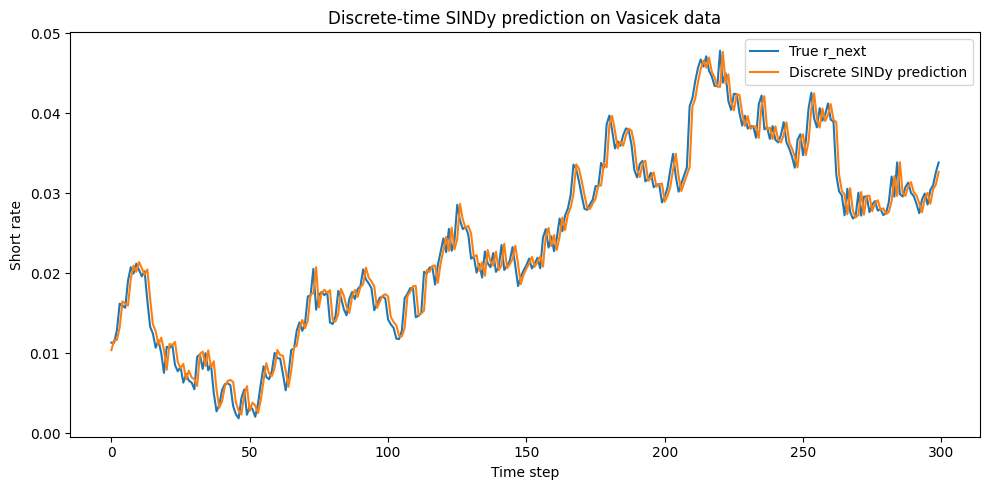

In [17]:
n_plot = 300

plt.figure(figsize=(10, 5))
plt.plot(Y_discrete[:n_plot], label="True r_next")
plt.plot(Y_discrete_hat[:n_plot], label="Discrete SINDy prediction")
plt.xlabel("Time step")
plt.ylabel("Short rate")
plt.title("Discrete-time SINDy prediction on Vasicek data")
plt.legend()
plt.tight_layout()
plt.show()


## Continuous-time SINDy

We estimate derivatives by forward finite differences:

`r_dot ≈ (r_next - r) / dt`

Then we fit:

`r_dot ≈ f(r)`

The theoretical Vasicek drift is:

`r_dot ≈ kappa * theta - kappa * r`


In [18]:
Xi_continuous, names_continuous, R_current, dRdt = fit_continuous_sindy(
    R_full,
    dt=dt,
    degree=1,
    threshold=0.00001,
    max_iter=10,
)

dRdt_hat = predict_derivative_continuous_sindy(
    R_current,
    Xi_continuous,
    degree=1,
)

continuous_mse = np.mean((dRdt - dRdt_hat) ** 2)
continuous_equation = format_equation(names_continuous, Xi_continuous, target_name="r_dot")

print("Feature names:", names_continuous)
print("Xi:")
print(Xi_continuous)
print("Recovered equation:")
print(continuous_equation)
print("MSE:", continuous_mse)


Feature names: ['1', 'x1']
Xi:
[[ 0.04953092]
 [-1.36932342]]
Recovered equation:
r_dot = 0.049531 + -1.369323*x1
MSE: 0.03906745727339442


In [19]:
expected_continuous_constant = kappa * theta
expected_continuous_linear = -kappa

print("Expected continuous-time drift:")
print(f"r_dot ≈ {expected_continuous_constant:.6f} + {expected_continuous_linear:.6f}*r")


Expected continuous-time drift:
r_dot ≈ 0.045000 + -1.500000*r


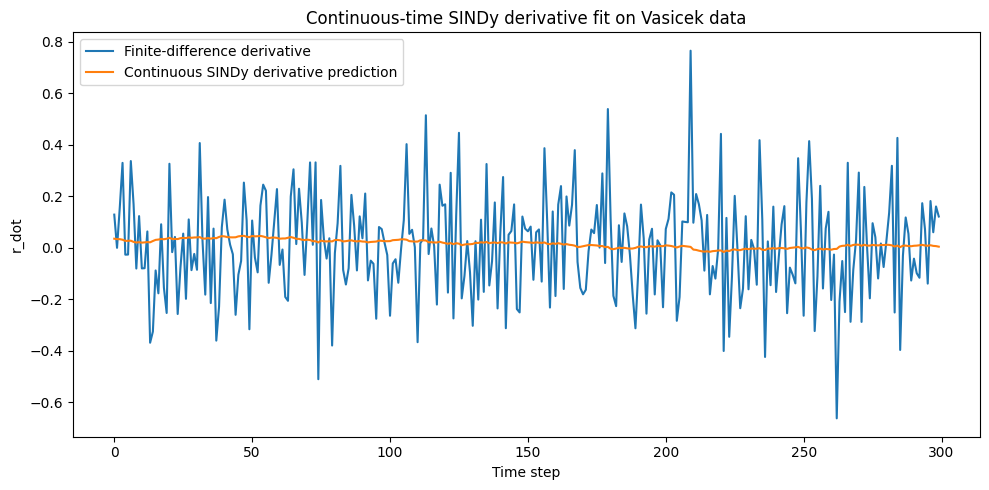

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(dRdt[:n_plot], label="Finite-difference derivative")
plt.plot(dRdt_hat[:n_plot], label="Continuous SINDy derivative prediction")
plt.xlabel("Time step")
plt.ylabel("r_dot")
plt.title("Continuous-time SINDy derivative fit on Vasicek data")
plt.legend()
plt.tight_layout()
plt.show()


## Interpretation

The discrete-time SINDy model closely recovers the one-step Vasicek dynamics.

Expected discrete-time model:

`r_next ≈ 0.000450 + 0.985000 * r`

Recovered discrete-time model:

`r_next ≈ 0.000495 + 0.986307 * r`

The continuous-time SINDy model also recovers the qualitative mean-reverting drift structure.

Expected continuous-time drift:

`r_dot ≈ 0.045000 - 1.500000 * r`

Recovered continuous-time drift:

`r_dot ≈ 0.049531 - 1.369323 * r`

The continuous-time estimate is less accurate than the discrete-time estimate because finite-difference derivative estimation amplifies stochastic noise.